## Summary

This analysis provides comprehensive evaluation of the loan prediction model including:

### Key Outputs:
1. **Confusion Matrices** - Shows True/False Positives and Negatives for both train and test sets
2. **ROC Curves** - Visualizes model's ability to discriminate between loan approval classes
3. **Performance Metrics** - Accuracy, Precision, Recall, F1-Score, and ROC-AUC
4. **Additional Visualizations** - Metrics comparison, probability distributions, and prediction analysis

### Key Metrics Explained:
- **Accuracy**: Overall correctness of the model
- **Precision**: Of predicted approvals, how many were correct
- **Recall (Sensitivity)**: Of actual approvals, how many did we catch
- **F1-Score**: Harmonic mean of precision and recall
- **ROC-AUC**: Area under the ROC curve (0.5 = random, 1.0 = perfect)

### Generated Files:
- `confusion_matrix_comparison.png` - Side-by-side confusion matrices
- `roc_curve.png` - ROC curves for train and test sets
- `additional_metrics_visualization.png` - Comprehensive metrics and distributions

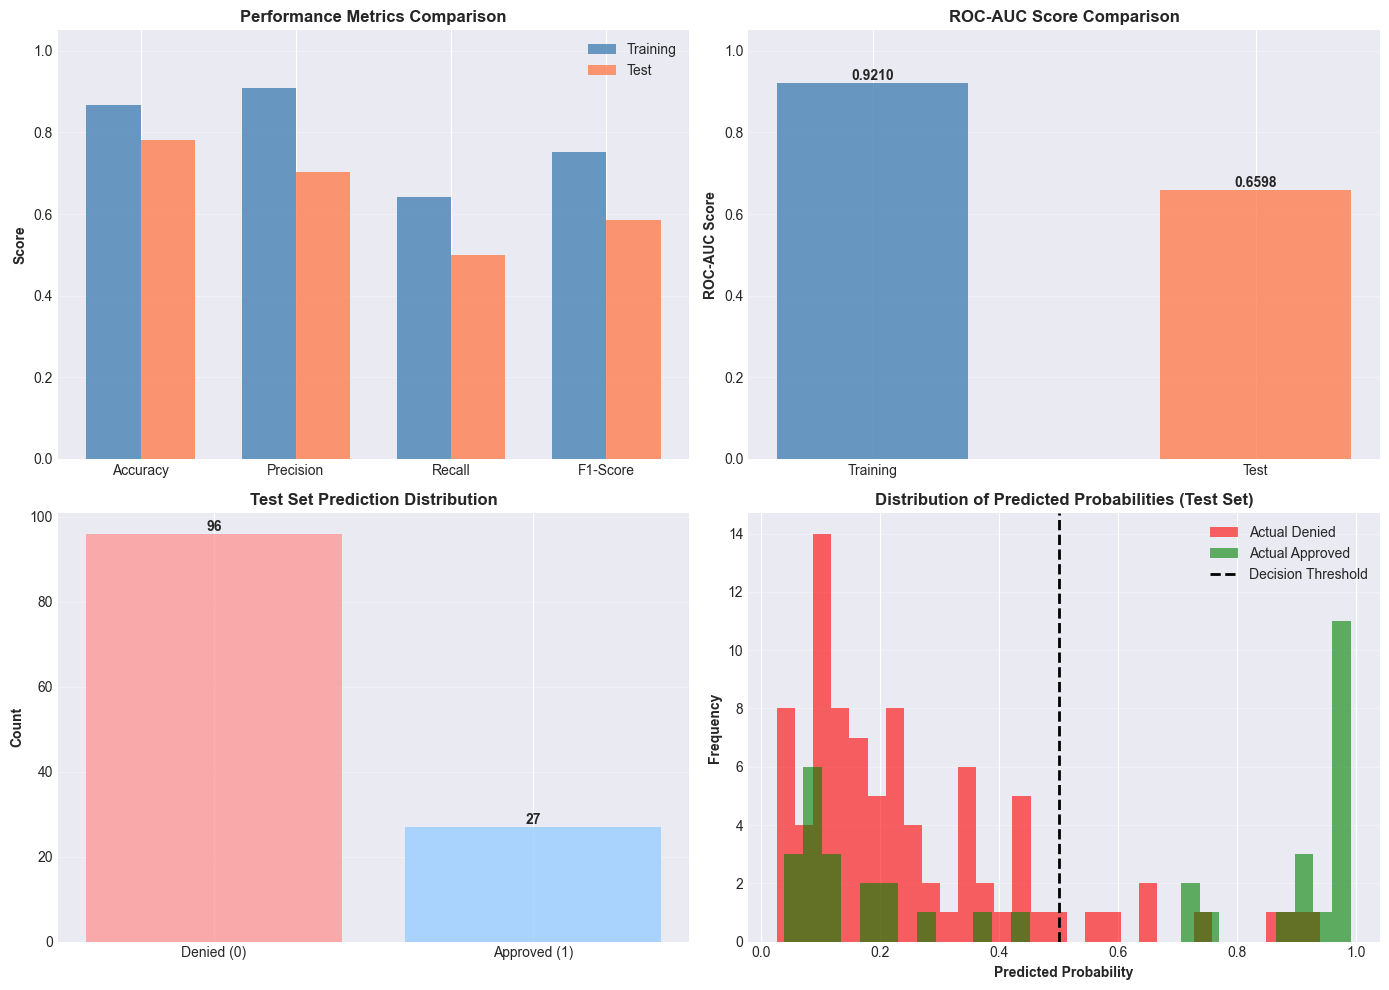

✓ Additional visualizations plotted and saved as 'additional_metrics_visualization.png'


In [21]:
# 10. BONUS: Additional Visualizations
if model is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Metrics Comparison Bar Chart
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    train_values = [train_accuracy, train_precision, train_recall, train_f1]
    test_values = [test_accuracy, test_precision, test_recall, test_f1]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, train_values, width, label='Training', alpha=0.8, color='steelblue')
    axes[0, 0].bar(x + width/2, test_values, width, label='Test', alpha=0.8, color='coral')
    axes[0, 0].set_ylabel('Score', fontweight='bold')
    axes[0, 0].set_title('Performance Metrics Comparison', fontweight='bold')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(metrics)
    axes[0, 0].legend()
    axes[0, 0].set_ylim([0, 1.05])
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. ROC-AUC Comparison
    auc_values = [roc_auc_train, roc_auc_test]
    colors = ['steelblue', 'coral']
    bars = axes[0, 1].bar(['Training', 'Test'], auc_values, color=colors, alpha=0.8, width=0.5)
    axes[0, 1].set_ylabel('ROC-AUC Score', fontweight='bold')
    axes[0, 1].set_title('ROC-AUC Score Comparison', fontweight='bold')
    axes[0, 1].set_ylim([0, 1.05])
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Prediction Distribution (Test Set)
    unique, counts = np.unique(y_test_pred, return_counts=True)
    axes[1, 0].bar(['Denied (0)', 'Approved (1)'], counts, color=['#ff9999', '#99ccff'], alpha=0.8)
    axes[1, 0].set_ylabel('Count', fontweight='bold')
    axes[1, 0].set_title('Test Set Prediction Distribution', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, count in enumerate(counts):
        axes[1, 0].text(i, count, str(count), ha='center', va='bottom', fontweight='bold')
    
    # 4. Predicted Probability Distribution (Test Set)
    axes[1, 1].hist(y_test_pred_proba[y_test == 0], bins=30, alpha=0.6, label='Actual Denied', color='red')
    axes[1, 1].hist(y_test_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Actual Approved', color='green')
    axes[1, 1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
    axes[1, 1].set_xlabel('Predicted Probability', fontweight='bold')
    axes[1, 1].set_ylabel('Frequency', fontweight='bold')
    axes[1, 1].set_title('Distribution of Predicted Probabilities (Test Set)', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('additional_metrics_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Additional visualizations plotted and saved as 'additional_metrics_visualization.png'")

In [20]:
# 9. Evaluate Model Performance - Comprehensive Metrics
if model is not None:
    print("="*70)
    print("COMPREHENSIVE MODEL EVALUATION METRICS")
    print("="*70)
    
    # Training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    
    print("\n📊 TRAINING SET METRICS:")
    print("-" * 70)
    print(f"  Accuracy:   {train_accuracy:.4f}")
    print(f"  Precision:  {train_precision:.4f}")
    print(f"  Recall:     {train_recall:.4f}")
    print(f"  F1-Score:   {train_f1:.4f}")
    print(f"  ROC-AUC:    {roc_auc_train:.4f}")
    
    # Test metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    
    print("\n📊 TEST SET METRICS:")
    print("-" * 70)
    print(f"  Accuracy:   {test_accuracy:.4f}")
    print(f"  Precision:  {test_precision:.4f}")
    print(f"  Recall:     {test_recall:.4f}")
    print(f"  F1-Score:   {test_f1:.4f}")
    print(f"  ROC-AUC:    {roc_auc_test:.4f}")
    
    # Classification Report
    print("\n" + "="*70)
    print("DETAILED CLASSIFICATION REPORT (TEST SET)")
    print("="*70)
    print(classification_report(y_test, y_test_pred, 
                               target_names=['Loan Denied (0)', 'Loan Approved (1)']))
    
    # Summary metrics table
    print("\n" + "="*70)
    print("METRICS SUMMARY TABLE")
    print("="*70)
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
        'Training': [f"{train_accuracy:.4f}", f"{train_precision:.4f}", 
                    f"{train_recall:.4f}", f"{train_f1:.4f}", f"{roc_auc_train:.4f}"],
        'Test': [f"{test_accuracy:.4f}", f"{test_precision:.4f}", 
                f"{test_recall:.4f}", f"{test_f1:.4f}", f"{roc_auc_test:.4f}"]
    })
    print(metrics_df.to_string(index=False))
    
    # Model interpretation
    print("\n" + "="*70)
    print("MODEL INTERPRETATION & RECOMMENDATIONS")
    print("="*70)
    
    # Check for overfitting/underfitting
    train_test_diff = abs(train_accuracy - test_accuracy)
    if train_test_diff > 0.1:
        print(f"⚠️  Possible overfitting detected (Train Acc: {train_accuracy:.4f}, Test Acc: {test_accuracy:.4f})")
    elif train_accuracy < 0.7 and test_accuracy < 0.7:
        print(f"⚠️  Model performance may need improvement (Test Acc: {test_accuracy:.4f})")
    else:
        print(f"✓  Model shows balanced performance across train and test sets")
    
    # ROC-AUC interpretation
    if roc_auc_test >= 0.9:
        print(f"✓  Excellent discrimination ability (ROC-AUC: {roc_auc_test:.4f})")
    elif roc_auc_test >= 0.8:
        print(f"✓  Good discrimination ability (ROC-AUC: {roc_auc_test:.4f})")
    elif roc_auc_test >= 0.7:
        print(f"✓  Acceptable discrimination ability (ROC-AUC: {roc_auc_test:.4f})")
    else:
        print(f"⚠️  Poor discrimination ability (ROC-AUC: {roc_auc_test:.4f})")
    
    # Precision-Recall trade-off
    print(f"\nPrecision-Recall Trade-off (Test): Precision={test_precision:.4f}, Recall={test_recall:.4f}")
    if test_precision > test_recall:
        print("  → Model tends to be conservative (fewer false positives)")
    else:
        print("  → Model tends to be liberal (fewer false negatives)")
    
    print("\n" + "="*70)

COMPREHENSIVE MODEL EVALUATION METRICS

📊 TRAINING SET METRICS:
----------------------------------------------------------------------
  Accuracy:   0.8676
  Precision:  0.9083
  Recall:     0.6429
  F1-Score:   0.7529
  ROC-AUC:    0.9210

📊 TEST SET METRICS:
----------------------------------------------------------------------
  Accuracy:   0.7805
  Precision:  0.7037
  Recall:     0.5000
  F1-Score:   0.5846
  ROC-AUC:    0.6598

DETAILED CLASSIFICATION REPORT (TEST SET)
                   precision    recall  f1-score   support

  Loan Denied (0)       0.80      0.91      0.85        85
Loan Approved (1)       0.70      0.50      0.58        38

         accuracy                           0.78       123
        macro avg       0.75      0.70      0.72       123
     weighted avg       0.77      0.78      0.77       123


METRICS SUMMARY TABLE
   Metric Training   Test
 Accuracy   0.8676 0.7805
Precision   0.9083 0.7037
   Recall   0.6429 0.5000
 F1-Score   0.7529 0.5846
  ROC-AUC 

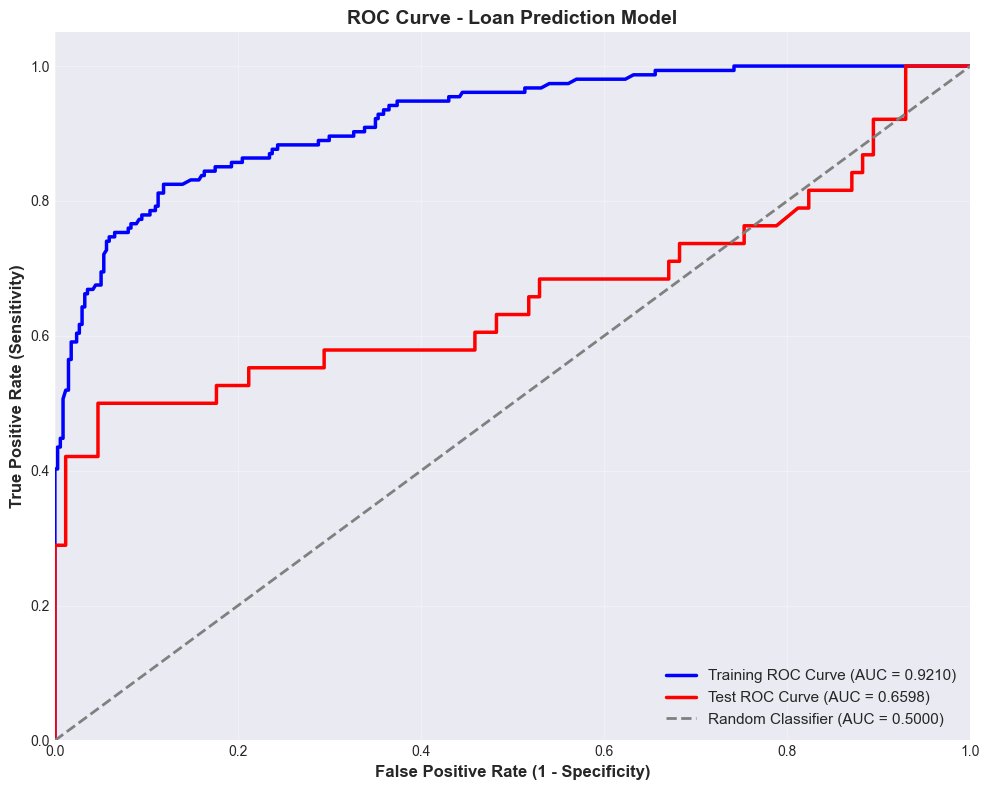

✓ ROC curves plotted and saved as 'roc_curve.png'


In [19]:
# 8. Plot ROC Curve
if model is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot training ROC curve
    ax.plot(fpr_train, tpr_train, color='blue', lw=2.5, 
            label=f'Training ROC Curve (AUC = {roc_auc_train:.4f})')
    
    # Plot test ROC curve
    ax.plot(fpr_test, tpr_test, color='red', lw=2.5, 
            label=f'Test ROC Curve (AUC = {roc_auc_test:.4f})')
    
    # Plot random classifier line
    ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5000)')
    
    # Customize plot
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
    ax.set_title('ROC Curve - Loan Prediction Model', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right", fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ ROC curves plotted and saved as 'roc_curve.png'")

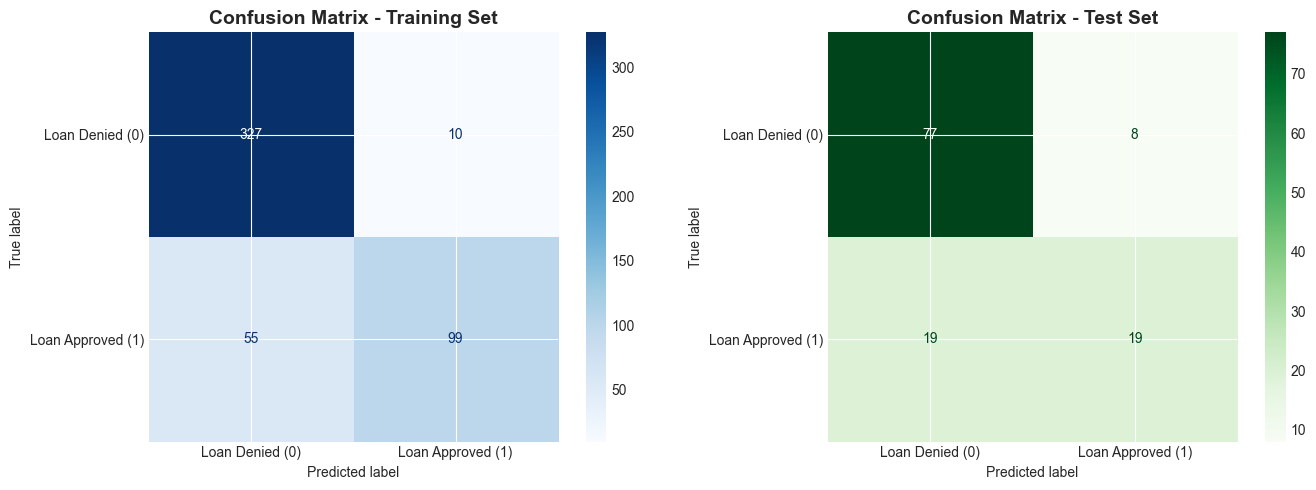

✓ Confusion matrices plotted and saved as 'confusion_matrix_comparison.png'


In [18]:
# 7. Plot Confusion Matrix
if model is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot training confusion matrix
    ConfusionMatrixDisplay(cm_train, display_labels=['Loan Denied (0)', 'Loan Approved (1)']).plot(
        ax=axes[0], cmap='Blues', values_format='d'
    )
    axes[0].set_title('Confusion Matrix - Training Set', fontsize=14, fontweight='bold')
    
    # Plot test confusion matrix
    ConfusionMatrixDisplay(cm_test, display_labels=['Loan Denied (0)', 'Loan Approved (1)']).plot(
        ax=axes[1], cmap='Greens', values_format='d'
    )
    axes[1].set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Confusion matrices plotted and saved as 'confusion_matrix_comparison.png'")

In [17]:
# 6. Calculate ROC Curve Metrics
if model is not None:
    # Calculate ROC curve for training set
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_pred_proba)
    roc_auc_train = auc(fpr_train, tpr_train)
    
    # Calculate ROC curve for test set
    fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred_proba)
    roc_auc_test = auc(fpr_test, tpr_test)
    
    print("ROC Curve Metrics - Training Set:")
    print(f"  AUC Score: {roc_auc_train:.4f}")
    print(f"  ROC_AUC_Score: {roc_auc_score(y_train, y_train_pred_proba):.4f}")
    
    print("\nROC Curve Metrics - Test Set:")
    print(f"  AUC Score: {roc_auc_test:.4f}")
    print(f"  ROC_AUC_Score: {roc_auc_score(y_test, y_test_pred_proba):.4f}")
    
    print(f"\n✓ ROC curves calculated successfully")

ROC Curve Metrics - Training Set:
  AUC Score: 0.9210
  ROC_AUC_Score: 0.9210

ROC Curve Metrics - Test Set:
  AUC Score: 0.6598
  ROC_AUC_Score: 0.6598

✓ ROC curves calculated successfully


In [16]:
# 5. Create Confusion Matrix
if model is not None:
    # Calculate confusion matrices
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)
    
    print("Confusion Matrix - Training Set:")
    print(cm_train)
    print("\nConfusion Matrix - Test Set:")
    print(cm_test)
    
    # Interpret confusion matrix
    print("\n" + "="*50)
    print("TRAIN SET CONFUSION MATRIX INTERPRETATION:")
    print("="*50)
    tn_train, fp_train, fn_train, tp_train = cm_train.ravel()
    print(f"True Negatives (TN):  {tn_train}")
    print(f"False Positives (FP): {fp_train}")
    print(f"False Negatives (FN): {fn_train}")
    print(f"True Positives (TP):  {tp_train}")
    
    print("\n" + "="*50)
    print("TEST SET CONFUSION MATRIX INTERPRETATION:")
    print("="*50)
    tn_test, fp_test, fn_test, tp_test = cm_test.ravel()
    print(f"True Negatives (TN):  {tn_test}")
    print(f"False Positives (FP): {fp_test}")
    print(f"False Negatives (FN): {fn_test}")
    print(f"True Positives (TP):  {tp_test}")

Confusion Matrix - Training Set:
[[327  10]
 [ 55  99]]

Confusion Matrix - Test Set:
[[77  8]
 [19 19]]

TRAIN SET CONFUSION MATRIX INTERPRETATION:
True Negatives (TN):  327
False Positives (FP): 10
False Negatives (FN): 55
True Positives (TP):  99

TEST SET CONFUSION MATRIX INTERPRETATION:
True Negatives (TN):  77
False Positives (FP): 8
False Negatives (FN): 19
True Positives (TP):  19


In [15]:
# 4. Generate Predictions
# Make predictions on training and test sets
if model is not None:
    try:
        # For pipeline: we can pass original dataframes directly
        y_train_pred_proba = model.predict_proba(X_train_df)
        y_train_pred = model.predict(X_train_df)
        
        y_test_pred_proba = model.predict_proba(X_test_df)
        y_test_pred = model.predict(X_test_df)
        
        # Handle multi-class case - take probability of class 1
        if len(y_train_pred_proba.shape) > 1 and y_train_pred_proba.shape[1] > 1:
            y_train_pred_proba = y_train_pred_proba[:, 1]
            y_test_pred_proba = y_test_pred_proba[:, 1]
        
        print("✓ Predictions generated successfully")
        print(f"\nTrain predictions - Proba shape: {y_train_pred_proba.shape}, Pred shape: {y_train_pred.shape}")
        print(f"Test predictions - Proba shape: {y_test_pred_proba.shape}, Pred shape: {y_test_pred.shape}")
        print(f"\nTrain predictions distribution: {np.bincount(y_train_pred)}")
        print(f"Test predictions distribution: {np.bincount(y_test_pred)}")
    except Exception as e:
        print(f"✗ Error making predictions: {e}")
        model = None
else:
    print("✗ Model not available. Skipping predictions.")

✓ Predictions generated successfully

Train predictions - Proba shape: (491,), Pred shape: (491,)
Test predictions - Proba shape: (123,), Pred shape: (123,)

Train predictions distribution: [382 109]
Test predictions distribution: [96 27]


In [14]:
# 3. Load Trained Model
# Load the saved model pipeline
MODEL_PATH = 'models/pipeline_xgb.joblib'

try:
    loaded_model = joblib.load(MODEL_PATH)
    
    # Check if it's a pipeline with named steps or a dict
    if hasattr(loaded_model, 'named_steps'):
        model = loaded_model
        print(f"✓ Model loaded successfully from {MODEL_PATH}")
        print(f"Model type: Pipeline with steps - {list(model.named_steps.keys())}")
    elif isinstance(loaded_model, dict) and 'model' in loaded_model:
        model = loaded_model
        print(f"✓ Model loaded successfully from {MODEL_PATH}")
        print(f"Model structure: Dict with keys - {list(model.keys())}")
    else:
        model = loaded_model
        print(f"✓ Model loaded successfully from {MODEL_PATH}")
        print(f"Model type: {type(model).__name__}")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    print("Note: If model not found, the training process will be skipped.")
    model = None

if model is not None:
    print(f"✓ Model is ready for prediction")

✓ Model loaded successfully from models/pipeline_xgb.joblib
Model type: Pipeline with steps - ['preprocessor', 'clf']
✓ Model is ready for prediction


In [13]:
# 2. Load and Prepare Data
# Load the dataset
CSV_PATH = 'data/loan_data2.csv'
df = pd.read_csv(CSV_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

# Define features
cat_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
num_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
FEATURES = cat_features + num_features
TARGET = 'Loan_Status'

# Data preprocessing - encode target and categorical variables
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Property_Area'] = df['Property_Area'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2})
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(float)

# Target encoding (Y=0, N=1)
df[TARGET] = df[TARGET].map({'Y': 0, 'N': 1})

# Handle missing values
for c in num_features:
    df[c] = df[c].fillna(df[c].median())
for c in cat_features:
    df[c] = df[c].astype(str).fillna('Missing')

# Extract features and target
X_df = df[FEATURES]
y = df[TARGET].values

# Split into train and test sets
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTraining set size: {X_train_df.shape}")
print(f"Test set size: {X_test_df.shape}")
print(f"Target distribution (train): {np.bincount(y_train)}")
print(f"Target distribution (test): {np.bincount(y_test)}")

# Create preprocessing pipeline
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features)
])

# Fit and transform data
preprocessor.fit(X_train_df)
X_train = preprocessor.transform(X_train_df).astype(float)
X_test = preprocessor.transform(X_test_df).astype(float)

print(f"\nPreprocessed training data shape: {X_train.shape}")
print(f"Preprocessed test data shape: {X_test.shape}")

Dataset shape: (614, 13)

First few rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0       

In [12]:
# 1. Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    auc, 
    roc_auc_score,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


# ROC Curve & Confusion Matrix Analysis
## Loan Prediction Model Evaluation

This notebook generates comprehensive evaluation metrics including ROC curves and confusion matrices for the loan prediction model.